In [1]:
import math

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from shapenet_dataset import ShapeNetDataset

# autoreload py
%load_ext autoreload
%autoreload 2

# Data Loading & Visualization

In [2]:
# pointcloud visualizer
def plot_pointclouds(pc_list):
    n = len(pc_list)
    n_cols = 4
    n_rows = math.ceil(n / n_cols)

    fig = plt.figure(figsize=(2 * n_cols, 2 * n_rows))
    fig.patch.set_facecolor('white')

    for i, (model_id, points) in enumerate(pc_list):
        ax = fig.add_subplot(n_rows, n_cols, i + 1, projection='3d')

        # convert to numpy if tensor
        if hasattr(points, "cpu"):
            points = points.cpu().numpy()

        ax.scatter(points[:, 0],points[:, 2],points[:, 1],s=2,c='dodgerblue',alpha=0.8)

        ax.set_title(f"ID: {str(model_id)[:8]}", fontsize=8)
        ax.set_axis_off()
        ax.set_box_aspect([1, 1, 1])

    # hide unused subplots
    total_plots = n_rows * n_cols
    for j in range(n, total_plots):
        ax = fig.add_subplot(n_rows, n_cols, j + 1, projection='3d')
        ax.set_axis_off()

    plt.subplots_adjust(wspace=0, hspace=0.1)
    plt.show()

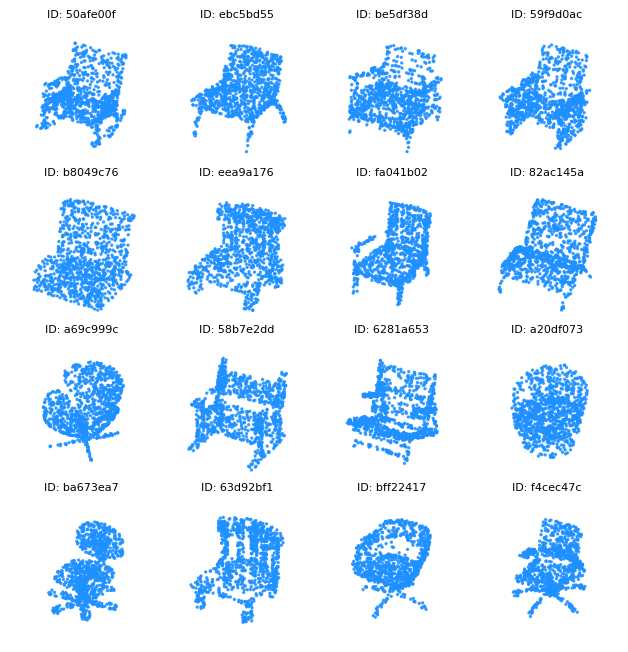

In [3]:
# raw mesh loader was very slow, precompute pointcloud as .npy instead
# dataset = ShapeNetDataset(data_dir='/ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/', object_class='03001627', num_points=1024)

dataset = ShapeNetDataset(data_dir='./sampled_poincloud/', object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list)
    break

## Experiment Flow

- Define model and loss directly in this notebook for each experiment.
- Use `run_training(...)` from `experiment_runner.py` for training loop, checkpoints, metrics, tqdm, and optional wandb.

## Experiment List
- Baseline 1: Base model (no seed), Loss: Chamfer.
- Baseline 2: Base model (no seed), Loss: Chamfer + Repulsion.

## Setting up

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from model import PointCloudAE
from pytorch3d.loss import chamfer_distance
import numpy as np

from experiment_runner import ExperimentConfig, run_training

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
batch_size = 16
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

device: cuda


## Baseline 1

In [5]:
import wandb
# wandb.login(key="")

/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [8]:
# 1) Baseline experiment: Chamfer Distance only
model_cd = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_cd = torch.optim.Adam(model_cd.parameters(), lr=lr)
loss_fn_cd = lambda recon, points: chamfer_distance(
    recon.float(),
    points.float(),
    batch_reduction="mean",
    point_reduction="mean",
)[0]

cfg_cd = ExperimentConfig(
    name="baseline_cd",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="runs",
)

run_dir_cd, summary_cd = run_training(
    config=cfg_cd,
    model=model_cd,
    optimizer=optimizer_cd,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)
print("Baseline CD run dir:", run_dir_cd)
print("Baseline CD summary:", summary_cd)

train:   0%|          | 0/382 [00:00<?, ?it/s]

val:   0%|          | 0/43 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>
Traceback (most recent call last):
  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
Exception ignored in: Exception ignored in:     Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>
<function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>

Traceback (most recent call last):

  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
Traceback (most recent call last):
  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
Traceback (most recent call last):
  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/si

[baseline_cd] epoch 001/100 train 0.015752 val 0.012315 best 0.012315


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>Exception ignored in:   File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__

<function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>Traceback (most recent call last):

  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    Traceback (most recent call last):
self._shutdown_workers()Exception ignored in:       File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__

<function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>self._shutdown_workers()  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/

...

train:   0%|          | 0/382 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0><function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>

Exception ignored in: Traceback (most recent call last):
Traceback (most recent call last):
  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7275974aa8c0>  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__

Traceback (most recent call last):
  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()    
    self._shutdown_workers()  File "/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
self._shutdown_workers()



KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x72750da39510>> (for post_run_cell), with arguments args (<ExecutionResult object at 72766864c820, execution_count=8 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 72766864c850, raw_cell="# 1) Baseline experiment: Chamfer Distance only
mo.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B10.204.100.123/ist-nas/users/pratchp/projects/shapevae/shapenet_train.ipynb#X12sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [ ]:
# 2) Baseline skeleton: Chamfer + Repulsion
# Keep model/optimizer definitions explicit; only loss changes.
model_rep = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_rep = torch.optim.Adam(model_rep.parameters(), lr=lr)

def repulsion_loss_placeholder(_pred_points):
    # TODO: implement your repulsion loss here.
    raise NotImplementedError("Implement repulsion loss before running this experiment")

def loss_fn_cd_plus_repulsion(recon, points):
    cd = chamfer_distance(
        recon,
        points,
        batch_reduction="mean",
        point_reduction="mean",
    )[0]
    rep = repulsion_loss_placeholder(recon)
    return cd + 0.1 * rep

cfg_cd_rep = ExperimentConfig(
    name="baseline_cd_plus_repulsion_skeleton",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="runs",
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
# run_dir_rep, summary_rep = run_training(
#     config=cfg_cd_rep,
#     model=model_rep,
#     optimizer=optimizer_rep,
#     loss_fn=loss_fn_cd_plus_repulsion,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
# )